<a href="https://colab.research.google.com/github/erikromerovelasco-dev/pandas-/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EJERCICIO 1 — Detección de zonas de entrega

DataFrame:
  Punto    X    Y
0    P1  1.0  1.0
1    P2  1.2  1.3
2    P3  0.8  0.9
3    P4  1.1  1.0
4    P5  5.0  5.0


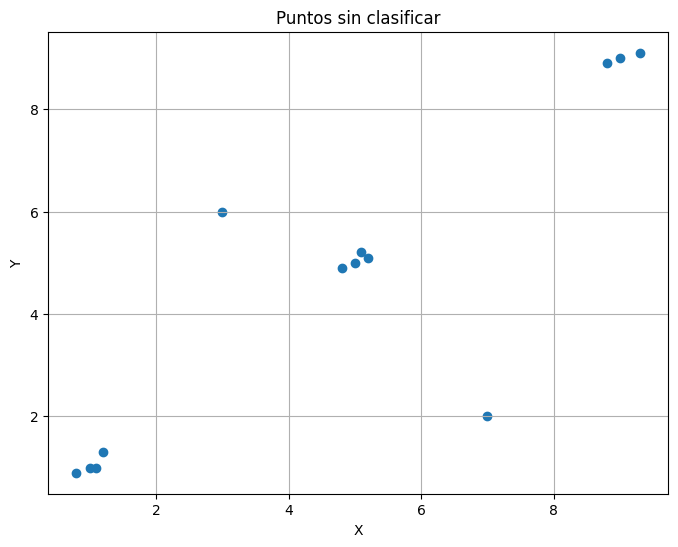


DataFrame con clusters:
  Punto    X    Y  Cluster
0    P1  1.0  1.0        0
1    P2  1.2  1.3        0
2    P3  0.8  0.9        0
3    P4  1.1  1.0        0
4    P5  5.0  5.0        1


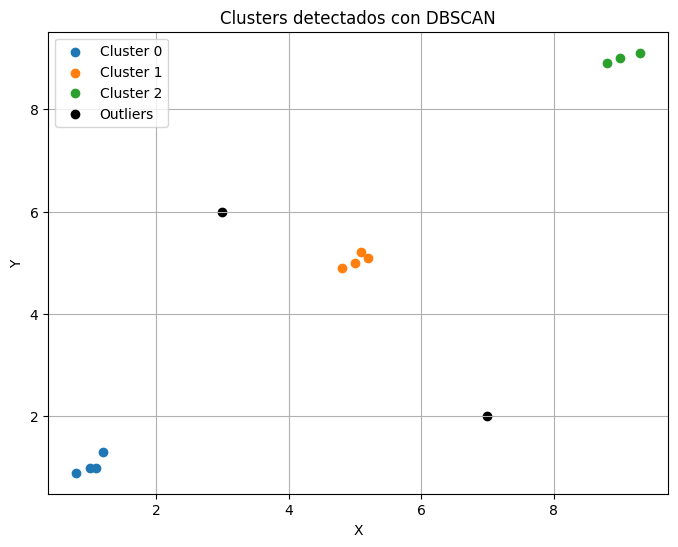


Número de zonas de entrega identificadas: 3


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. Crear el DataFrame con columnas X y Y

df = pd.read_csv('/content/ejercicio_1_zonas_entrega - ejercicio_1_zonas_entrega.csv')

print("DataFrame:")
print(df.head())

# 2. Graficar los puntos sin clasificar

plt.figure(figsize=(8,6))
plt.scatter(df['X'], df['Y'])
plt.title('Puntos sin clasificar')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()


# 3. Aplicar DBSCAN eps = 0.8 min_samples = 3

modelo = DBSCAN(eps=0.8, min_samples=3)

clusters = modelo.fit_predict(df[['X','Y']])

# 4. Agregar columna Cluster

df['Cluster'] = clusters

print("\nDataFrame con clusters:")
print(df.head())

# 5. Graficar clusters y outliers en negro

plt.figure(figsize=(8,6))

clusters_unicos = df['Cluster'].unique()

for cluster in clusters_unicos:

    datos_cluster = df[df['Cluster'] == cluster]

    if cluster == -1:
        plt.scatter(
            datos_cluster['X'],
            datos_cluster['Y'],
            color='black',
            label='Outliers'
        )
    else:
        plt.scatter(
            datos_cluster['X'],
            datos_cluster['Y'],
            label=f'Cluster {cluster}'
        )

plt.title('Clusters detectados con DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# 6. ¿Cuántas zonas identificó?

num_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print(f"\nNúmero de zonas de entrega identificadas: {num_clusters}")


EJERCICIO 2 — Segmentación de sensores ambientales

Primeras filas del DataFrame:
  Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado
0     S1           10.2         20.5      Frio/Seco
1     S2            9.8         19.1      Frio/Seco
2     S3           11.1         21.0      Frio/Seco
3     S4           35.5         80.2  Calido/Humedo
4     S5           34.1         78.5  Calido/Humedo

Datos escalados correctamente


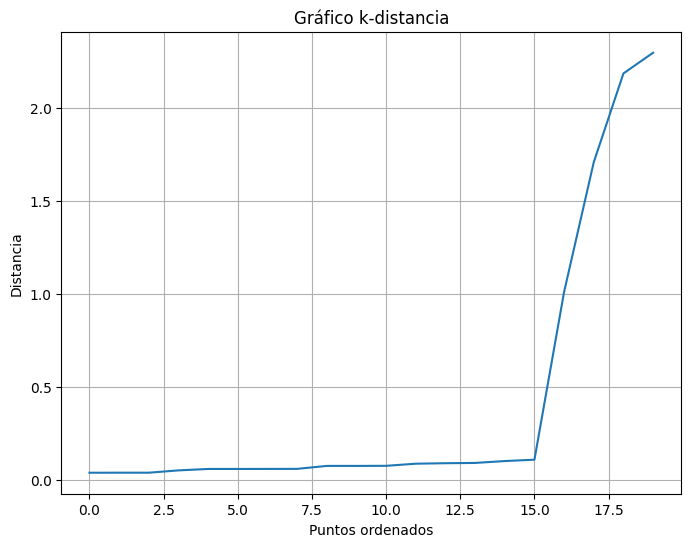


DataFrame con clusters:
  Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado  Cluster
0     S1           10.2         20.5      Frio/Seco        0
1     S2            9.8         19.1      Frio/Seco        0
2     S3           11.1         21.0      Frio/Seco        0
3     S4           35.5         80.2  Calido/Humedo        1
4     S5           34.1         78.5  Calido/Humedo        1


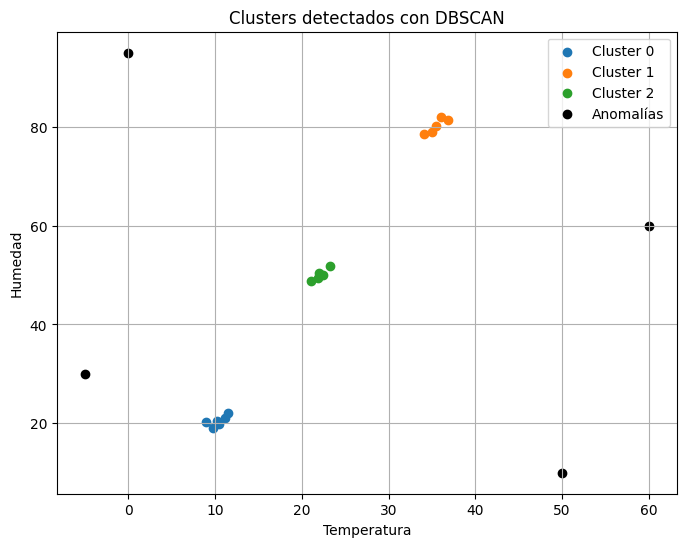


COMPARACIÓN DBSCAN vs K-MEANS
DBSCAN sí puede detectar anomalías porque identifica
puntos aislados como ruido (cluster = -1).

K-Means NO detecta anomalías directamente porque
obliga a que todos los puntos pertenezcan a un cluster,
incluyendo los datos atípicos.


In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Cargar y crear DataFrame

df = pd.read_csv('/content/sensores_amsensores_ambientales.csv')

print("Primeras filas del DataFrame:")
print(df.head())

# 2. Escalar datos con StandardScaler

X = df[['Temperatura_C', 'Humedad_pct']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDatos escalados correctamente")

# 3. Gráfico k-distancia para elegir eps

neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 2])

plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title('Gráfico k-distancia')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')
plt.grid(True)
plt.show()

eps_value = 0.5

# 4. Aplicar DBSCAN

dbscan = DBSCAN(eps=eps_value, min_samples=3)

clusters = dbscan.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nDataFrame con clusters:")
print(df.head())

# 5. Graficar clusters y anomalías

plt.figure(figsize=(8,6))

clusters_unicos = df['Cluster'].unique()

for cluster in clusters_unicos:

    datos_cluster = df[df['Cluster'] == cluster]

    if cluster == -1:
        plt.scatter(
            datos_cluster['Temperatura_C'],
            datos_cluster['Humedad_pct'],
            color='black',
            label='Anomalías'
        )
    else:
        plt.scatter(
            datos_cluster['Temperatura_C'],
            datos_cluster['Humedad_pct'],
            label=f'Cluster {cluster}'
        )

plt.title('Clusters detectados con DBSCAN')
plt.xlabel('Temperatura')
plt.ylabel('Humedad')
plt.legend()
plt.grid(True)
plt.show()

# 6. Comparación con K-Means

print("\nCOMPARACIÓN DBSCAN vs K-MEANS")
print("DBSCAN sí puede detectar anomalías porque identifica")
print("puntos aislados como ruido (cluster = -1).")

print("\nK-Means NO detecta anomalías directamente porque")
print("obliga a que todos los puntos pertenezcan a un cluster,")
print("incluyendo los datos atípicos.")


Ejercicio 3 — Análisis de patrones de fraude bancario

Primeras filas del DataFrame:
  Transaccion  Monto  Hora Perfil_Real
0          T1    510    13      Normal
1          T2    480    14      Normal
2          T3    550    12      Normal
3          T4    460    15      Normal
4          T5   4500     3  SOSPECHOSA

Datos escalados correctamente


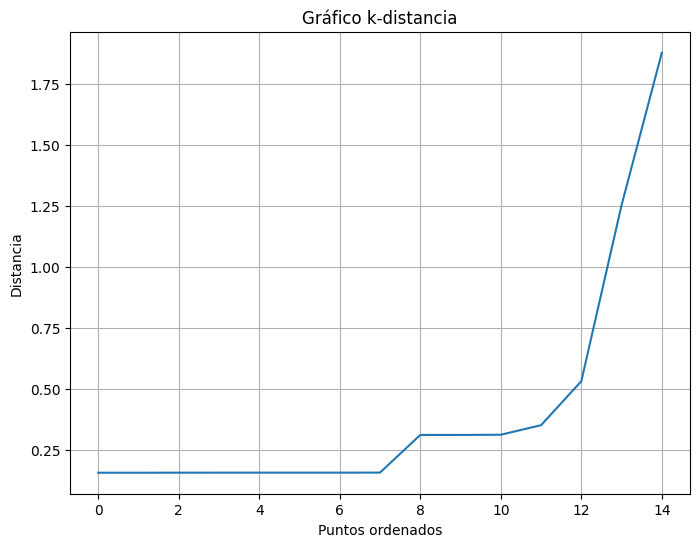


DataFrame con clasificación:
  Transaccion  Monto  Hora Perfil_Real  Cluster  Estado
0          T1    510    13      Normal        0  Normal
1          T2    480    14      Normal        0  Normal
2          T3    550    12      Normal        0  Normal
3          T4    460    15      Normal        0  Normal
4          T5   4500     3  SOSPECHOSA        1  Normal


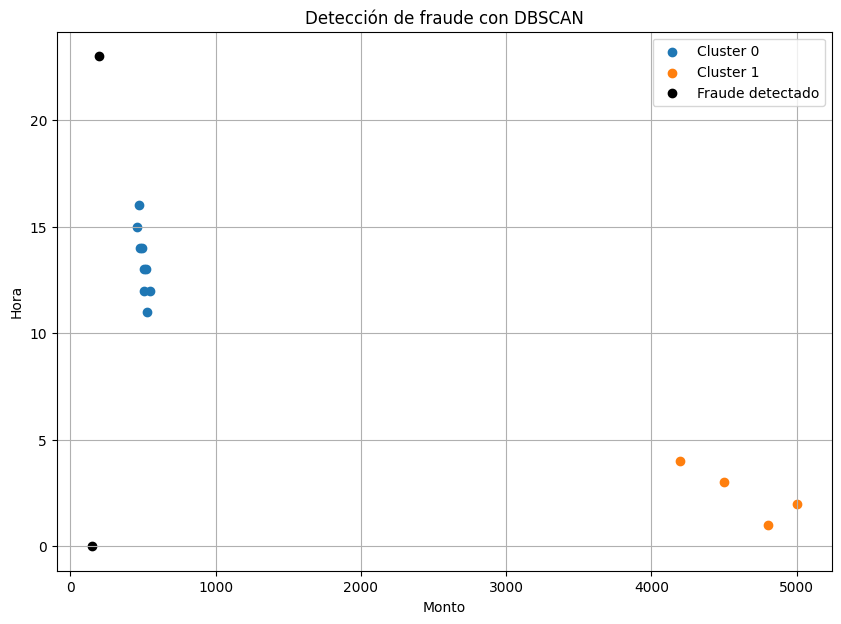


Total de transacciones: 15
Transacciones sospechosas: 2
Porcentaje sospechoso: 13.33%

REFLEXIÓN:
DBSCAN tiene ventaja sobre K-Means porque puede
detectar automáticamente datos aislados o atípicos
sin obligarlos a pertenecer a un cluster.

K-Means asigna todos los puntos a algún grupo,
por lo que las transacciones fraudulentas podrían
mezclarse con transacciones normales.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Crear DataFrame con columnas Monto y Hora

df = pd.read_csv('/content/fraude_bancario.csv')

print("Primeras filas del DataFrame:")
print(df.head())

# 2. Escalar los datos con StandardScaler

X = df[['Monto', 'Hora']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDatos escalados correctamente")

# 3. Gráfico k-distancia para determinar eps

neighbors = NearestNeighbors(n_neighbors=3)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 2])

plt.figure(figsize=(8,6))
plt.plot(distances)

plt.title('Gráfico k-distancia')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')

plt.grid(True)
plt.show()


eps_value = 0.5

# 4. Aplicar DBSCAN

dbscan = DBSCAN(eps=eps_value, min_samples=3)

clusters = dbscan.fit_predict(X_scaled)

df['Cluster'] = clusters

df['Estado'] = df['Cluster'].apply(
    lambda x: 'Sospechosa' if x == -1 else 'Normal'
)

print("\nDataFrame con clasificación:")
print(df.head())

# 5. Graficar transacciones

plt.figure(figsize=(10,7))

clusters_unicos = df['Cluster'].unique()

for cluster in clusters_unicos:

    datos_cluster = df[df['Cluster'] == cluster]

    if cluster == -1:
        plt.scatter(
            datos_cluster['Monto'],
            datos_cluster['Hora'],
            color='black',
            label='Fraude detectado'
        )

    else:
        plt.scatter(
            datos_cluster['Monto'],
            datos_cluster['Hora'],
            label=f'Cluster {cluster}'
        )

plt.title('Detección de fraude con DBSCAN')
plt.xlabel('Monto')
plt.ylabel('Hora')

plt.legend()
plt.grid(True)
plt.show()

# 6. Porcentaje de transacciones sospechosas

total = len(df)

sospechosas = len(df[df['Estado'] == 'Sospechosa'])

porcentaje = (sospechosas / total) * 100

print(f"\nTotal de transacciones: {total}")
print(f"Transacciones sospechosas: {sospechosas}")
print(f"Porcentaje sospechoso: {porcentaje:.2f}%")

# 7. Reflexión

print("\nREFLEXIÓN:")
print("DBSCAN tiene ventaja sobre K-Means porque puede")
print("detectar automáticamente datos aislados o atípicos")
print("sin obligarlos a pertenecer a un cluster.")

print("\nK-Means asigna todos los puntos a algún grupo,")
print("por lo que las transacciones fraudulentas podrían")
print("mezclarse con transacciones normales.")